# Statistics Pilot: Test Scores

This notebook renders several basic statistical graphics and summaries for a dataset of test scores from two different cohorts of students.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# Matplotlib defaults (kept simple for JupyterLite)
plt.rcParams["figure.figsize"] = (6, 4)

In [10]:
df = pd.read_csv("data/scores_cohorts.csv")

# normalize to strings so titles/labels are easy
df["cohort"] = df["cohort"].astype(str).str.strip()
df["cohort"] = pd.Categorical(df["cohort"], categories=["11", "12"], ordered=True)

df.head()

,cohort,1st-day,2nd-day,score
0,12,17,11,28
1,12,24,9,33
2,12,39,2,41
3,12,25,8,33
4,12,21,5,26


In [11]:
display(df.select_dtypes(include='number').describe().round(1))
print("Scores Summary:")
summary = (
    df.groupby('cohort', observed=True)['score']
      .agg(['count','mean','median','min','max','std'])
      .round(2)
)
summary

,1st-day,2nd-day,score
count,22.0,22.0,22.0
mean,23.3,9.0,32.3
std,6.7,4.3,4.7
min,14.0,2.0,25.0
25%,20.0,5.5,28.5
50%,22.5,9.0,32.5
75%,25.0,11.0,35.5
max,39.0,19.0,41.0


Scores Summary:


,count,mean,median,min,max,std
cohort,,,,,,
11,13,33.15,33.0,25,41,4.58
12,9,31.00,30.0,26,41,4.80


/var/folders/55/4f47qb0916v_q0mt1tj5n4lr0000gn/T/ipykernel_49628/3667053362.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, sub in df.groupby('cohort'):


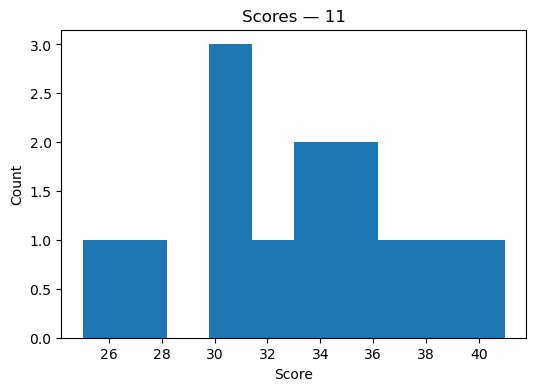

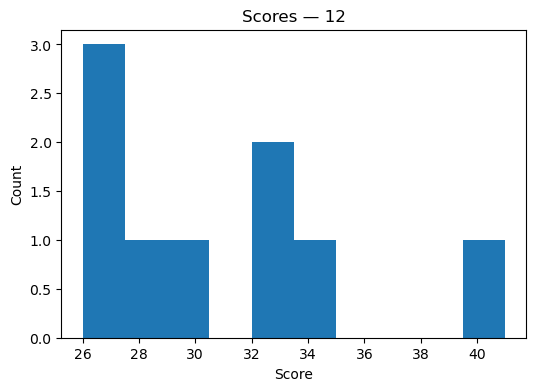

<Figure size 600x400 with 0 Axes>

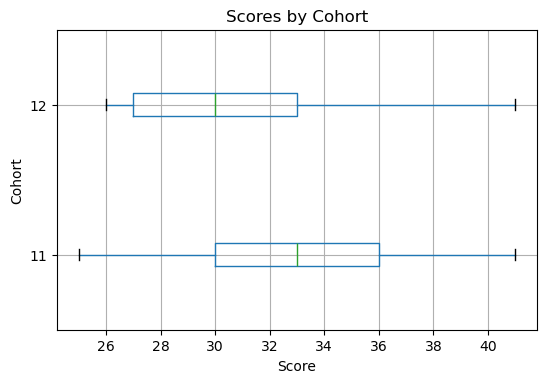

In [12]:
# Histogram by cohort
for grp, sub in df.groupby('cohort'):
    plt.figure()
    plt.hist(sub['score'])
    plt.title(f"Scores — {grp}")
    plt.xlabel("Score")
    plt.ylabel("Count")
    plt.show()

# Boxplot by cohort
plt.figure()
df.boxplot(column='score', by='cohort', vert=False)
plt.suptitle("")
plt.title("Scores by Cohort")
plt.xlabel("Score")
plt.ylabel("Cohort")
plt.show()


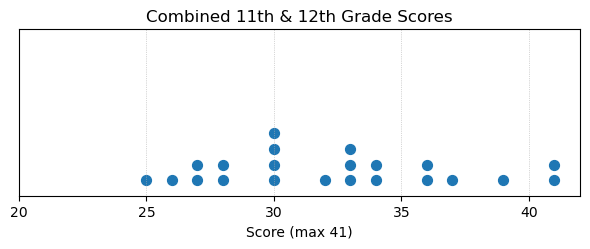

In [13]:
scores = df["score"].astype(int)
counts = scores.value_counts().sort_index()

spacing = 0.15                      # tighter stacking (smaller = tighter)
headroom = 1.0                      # extra space above the tallest stack (in y units)

x = np.concatenate([[v]*c for v,c in counts.items()])
y = np.concatenate([np.arange(c)*spacing + spacing for c in counts.values])

fig, ax = plt.subplots(figsize=(6, 2.6))   # short vertical figure
ax.scatter(x, y, s=50)
ax.set_title("Combined 11th & 12th Grade Scores")
ax.set_xlabel("Score (max 41)")

ticks = np.arange(20, 43, 5)
ax.set_xticks(ticks)
ax.set_xticklabels([f"{int(t)}" for t in ticks])

ax.set_yticks([])
ax.set_xlim(20, 42)
ax.set_ylim(0, counts.max()*spacing + headroom)  # manual y scale + extra space
ax.margins(y=0)                                  # disable auto top/bottom padding
ax.grid(axis="x", linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

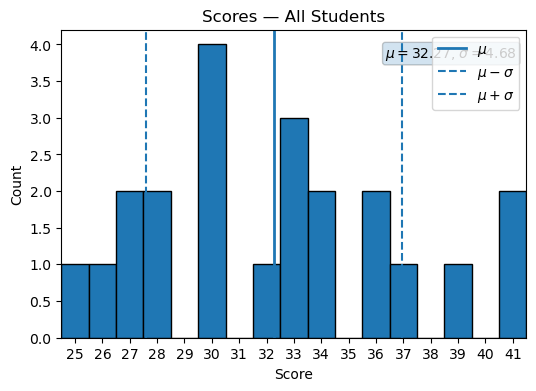

In [15]:
# Histogram — All students with mean (μ) and standard deviation (σ)

import numpy as np
import matplotlib.pyplot as plt

scores = df["score"].to_numpy()

# Center and spread (sample SD)
mu = float(np.mean(scores))
sigma = float(np.std(scores, ddof=1))   # ddof=1 → sample standard deviation

# Integer-centered bins to align with dot-plot ticks
lo, hi = np.floor(scores.min()), np.ceil(scores.max())
bins = np.arange(lo - 0.5, hi + 1.5, 1.0)

plt.figure()
plt.hist(scores, bins=bins, edgecolor="black")
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Scores — All Students")

# Annotate mean and ±1σ
plt.axvline(mu, linewidth=2, label=r"$\mu$")
plt.axvline(mu - sigma, linestyle="--", label=r"$\mu-\sigma$")
plt.axvline(mu + sigma, linestyle="--", label=r"$\mu+\sigma$")

# Show numeric values in a small textbox
ax = plt.gca()
ax.text(
    0.98, 0.95,
    rf"$\mu={mu:.2f}$, $\sigma={sigma:.2f}$",
    transform=ax.transAxes, ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.2", alpha=0.2)
)

plt.xticks(np.arange(lo, hi + 1, 1))
plt.xlim(lo - 0.5, hi + 0.5)
plt.legend()
plt.show()

## Linear transformation of scores

Goal: to map the 0 to 41 range of scores to a 0 to 100 scale.

**Notation.** Let $X=\{x_1,\dots,x_n\}$ with size $n$. 

Define $Y=aX+b$ so $y_i=ax_i+b$.

- Means: $\bar{y}=a\bar{x}+b$
- Medians: $\tilde{y}=a\tilde{x}+b$
- SD/Var: $\sigma_y=\lvert a\rvert \sigma_x,\quad \sigma_y^2=a^2 \sigma_x^2$
- IQR/Range: $\mathrm{IQR}_Y=\lvert a\rvert\,\mathrm{IQR}_X,\quad R_Y=\lvert a\rvert R_X$
- Adding $b$: shifts center; no change to spread.
- Multiplying by $a$: scales center by $a$ and spreads by $\lvert a\rvert$ (reflect if $a<0$).

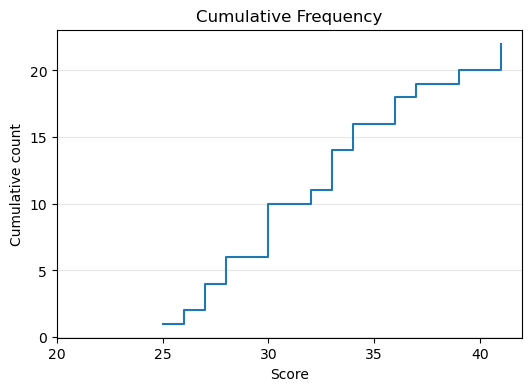

In [14]:
# Cumulative frequency chart (ECDF) aligned to integer score ticks

# Use df['score'] if present; otherwise fallback to a list/array named `values`
if 'df' in globals() and 'score' in getattr(df, 'columns', []):
    data = df['score'].to_numpy()
elif 'values' in globals():
    data = np.asarray(values)
else:
    raise NameError("Provide data as df['score'] or a list/array named `values`.")

data = np.asarray(data, dtype=float)
xs = np.sort(data)
cum_counts = np.arange(1, xs.size + 1)

# Integer tick marks to match a dot plot of raw scores
xmin, xmax = np.floor(xs.min()), np.ceil(xs.max())

plt.figure()
plt.step(xs, cum_counts, where='post')
plt.xlim(20, 42)
# plt.xlim(xmin - 0.5, xmax + 0.5)
plt.xticks(np.arange(20, 42, 5))
# plt.xticks(np.arange(xmin, xmax + 1, 1))
plt.xlabel("Score")
plt.ylabel("Cumulative count")
plt.title("Cumulative Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

# Optional: cumulative relative frequency (percent)
# plt.figure()
# plt.step(xs, 100 * cum_counts / len(xs), where='post')
# plt.xlim(xmin - 0.5, xmax + 0.5)
# plt.xticks(np.arange(xmin, xmax + 1, 1))
# plt.xlabel("Score")
# plt.ylabel("Cumulative percent")
# plt.title("Cumulative Relative Frequency")
# plt.grid(axis='y', alpha=0.3)
# plt.show()